In [14]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
import cme.simulators.diffusion_random_walk as drw

sns.set_context("paper", font_scale=2.5)
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [2]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 3, 0.5, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [3]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [52]:
theta, alpha, tau = 11, 1.5, 0.5

mu, sigma = np.asarray([1]), np.asarray([2])

n_states = drw._get_n_states(alpha, theta, tau, sigma)
discrete_transition_matrix = drw.get_transition_matrix(alpha, tau, sigma[0], mu, process="Wiener", n_states=n_states).round(decimals=2)
discrete_transition_matrix

array([[0.33, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.27, 0.33, 0.39, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.27, 0.33, 0.39, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.27, 0.33, 0.39, 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.27, 0.33, 0.39, 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.27, 0.33, 0.39, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.27, 0.33, 0.39, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.27, 0.33, 0.39, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.27, 0.33, 0.39, 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.27, 0.33, 0.39],
       [0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.33]])

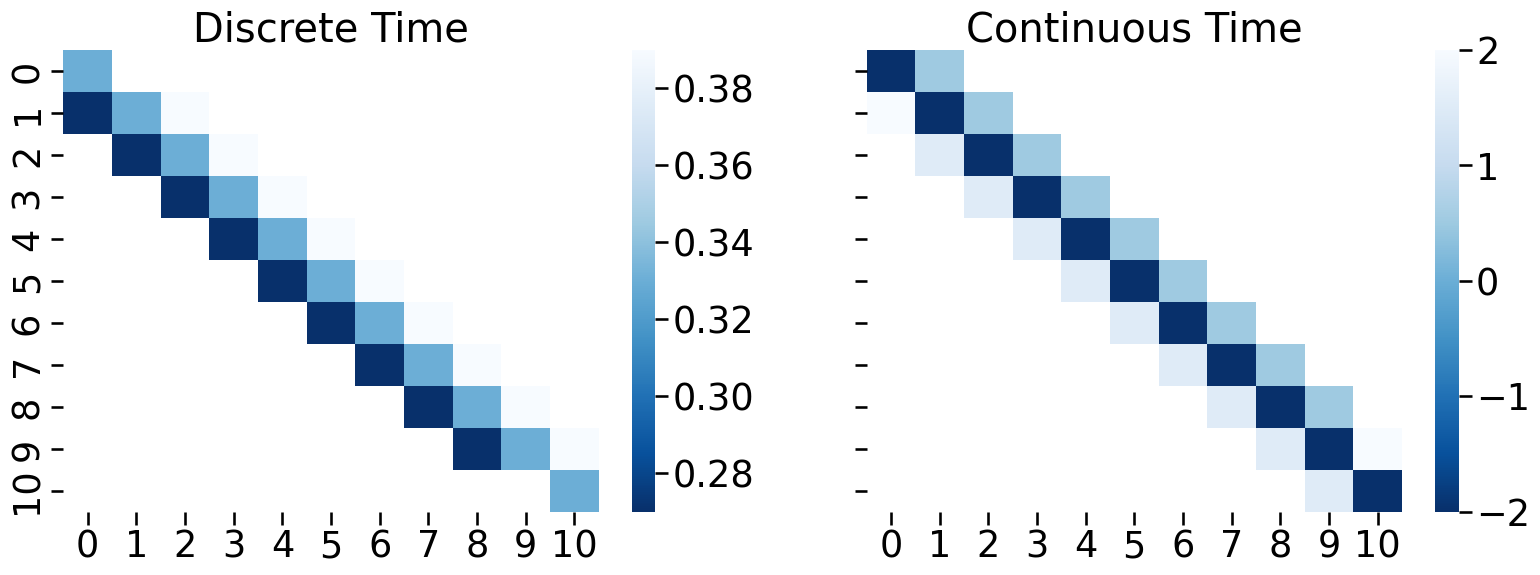

In [53]:
with sns.plotting_context("talk", font_scale=1.6):
    fig, axs = plt.subplots(1,2, figsize=(19,6), sharex=True, sharey=True)
    sns.heatmap(np.where(discrete_transition_matrix==0,np.nan,discrete_transition_matrix),  
    cmap = "Blues_r", ax=axs[0])
    axs[0].set_title("Discrete Time")
    sns.heatmap(np.where(intensity_matrix_markov.squeeze()==0,np.nan,intensity_matrix_markov.squeeze()) ,
    cmap = "Blues_r", ax=axs[1])
    axs[1].set_title("Continuous Time")


<Axes: >

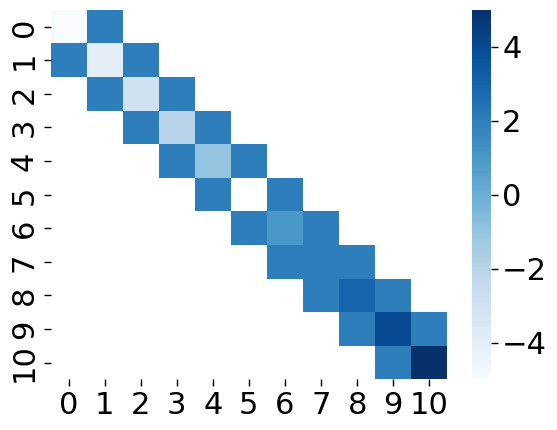

In [5]:
intensity_t = -np.imag(intensity_matrix_quantum.squeeze())
sns.heatmap(np.where(intensity_t==0,np.nan,intensity_t), cmap = "Blues")

In [54]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Uniform")
phi_0_markov, phi_0_quantum

(Array([[[[0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909]]]], dtype=float64),
 Array([[[[0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134],
          [0.30151134]]]], dtype=float64))

In [55]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
    
    for t in np.arange(1,10/delta,delta):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,10/delta,delta):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [8]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-5,Upper,0.0,0.0010307047953597632,0.0011898423158405822
1,-4,Upper,0.0,-0.0017253224846249516,0.005646517479209136
2,-3,Upper,0.0,-0.018980010558265405,0.0044566751633685585
3,-2,Upper,0.0,-0.03694126967340451,-0.037930952395820346
4,-1,Upper,0.0,0.025832128003517665,-0.10787348588288555
...,...,...,...,...,...
1249,1,Lower,3.7,-0.03939246817153469,0.5213915535108343
1250,2,Lower,3.7,0.24733636100719458,-0.40809731096394636
1251,3,Lower,3.7,-0.27801540072652864,0.1004688756676902
1252,4,Lower,3.7,0.17851346854016986,0.05072907204703718


In [9]:
import plotly.express as px
pio.renderers.default = "browser" #"vscode" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Random Walk - Probability "Amplitude" (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "Conf States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
#fig.show()
#import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [11]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*delta).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

In [56]:
RT_arr, X_arr, steps_arr = drw.gen_rt_x(theta, alpha, tau, sigma[0], mu,samples = 100, process="Wiener",njobs=1, scale_steps=False)
RT_arr

[7.5,
 26.0,
 22.5,
 23.0,
 49.5,
 12.0,
 20.0,
 7.0,
 7.0,
 1.0,
 4.0,
 2.5,
 12.5,
 3.0,
 4.0,
 7.0,
 6.5,
 38.0,
 7.5,
 3.0,
 3.0,
 9.0,
 11.5,
 39.5,
 0.5,
 11.0,
 1.5,
 56.0,
 13.5,
 16.0,
 4.5,
 4.0,
 30.0,
 12.0,
 12.5,
 14.0,
 2.5,
 15.0,
 9.5,
 16.5,
 5.5,
 7.5,
 7.5,
 6.5,
 1.0,
 6.0,
 5.0,
 8.0,
 2.0,
 2.0,
 1.5,
 13.5,
 1.5,
 4.0,
 41.5,
 11.5,
 5.5,
 7.5,
 27.5,
 13.0,
 12.0,
 7.5,
 15.5,
 21.5,
 2.0,
 26.5,
 12.0,
 19.0,
 6.5,
 2.5,
 5.5,
 27.5,
 24.5,
 3.5,
 15.5,
 15.0,
 2.0,
 4.5,
 9.5,
 1.5,
 26.5,
 25.5,
 7.0,
 16.5,
 2.0,
 8.5,
 12.5,
 8.5,
 2.5,
 12.5,
 7.5,
 27.5,
 38.5,
 12.0,
 21.0,
 9.5,
 27.0,
 41.0,
 2.5,
 11.5]

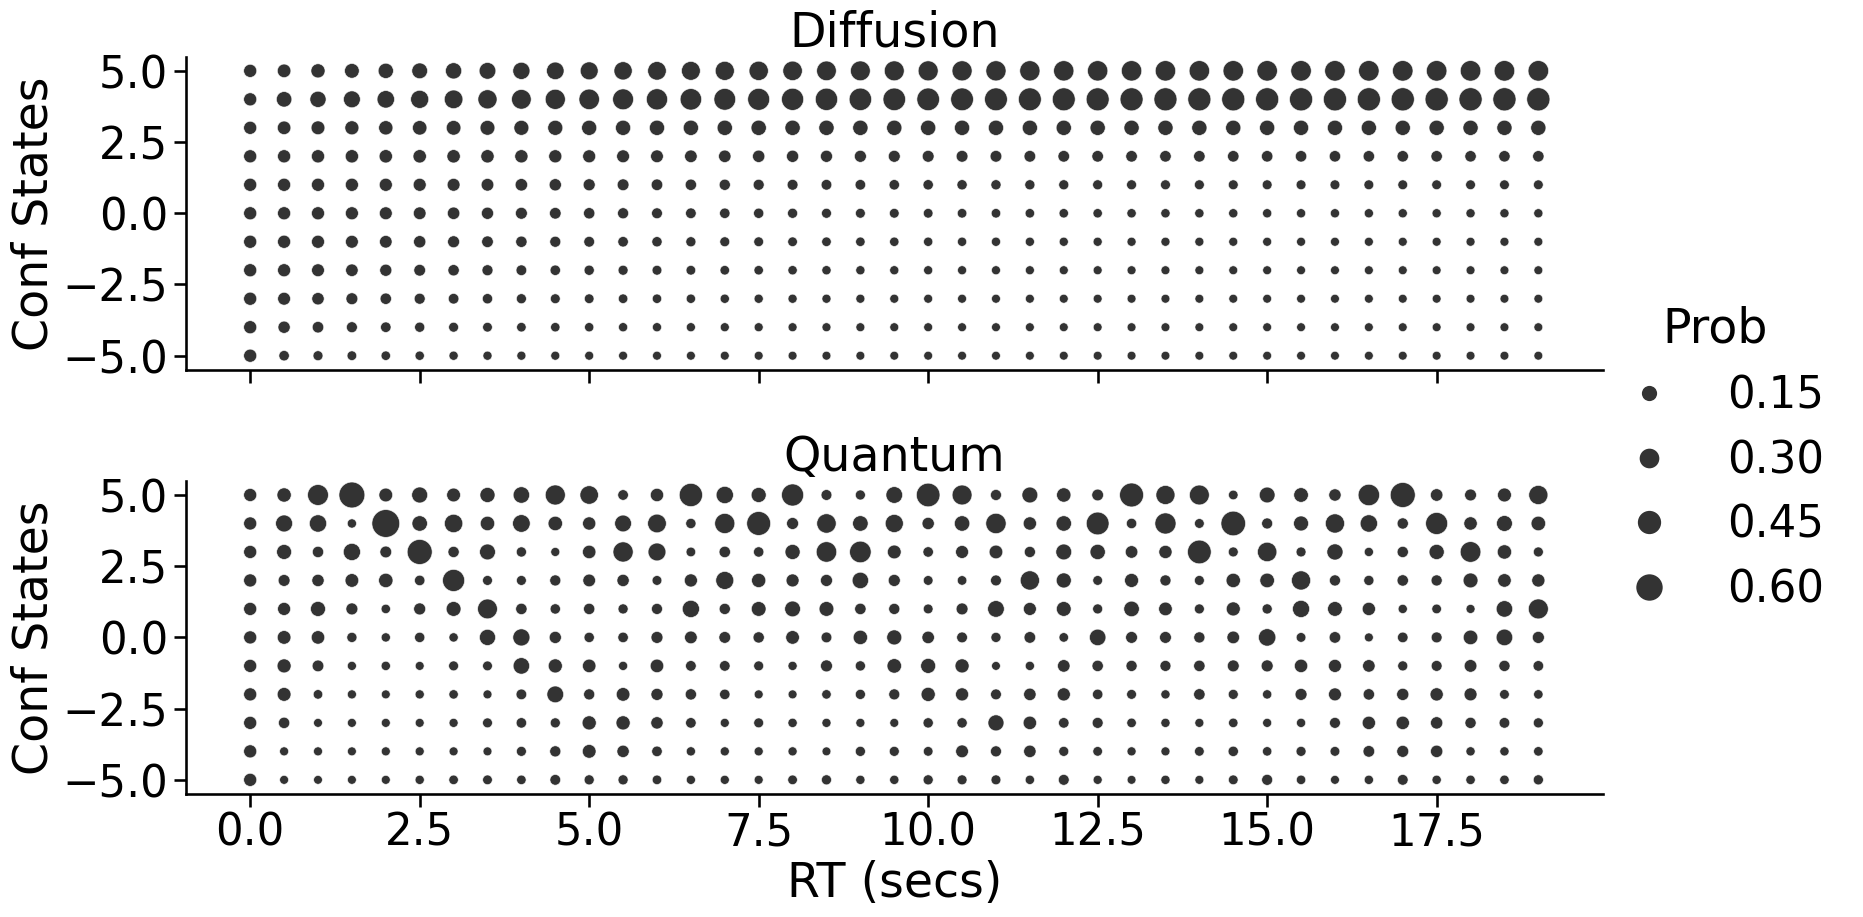

In [12]:
with sns.plotting_context("talk",font_scale=1.9):
    f = sns.relplot(pd.concat([df_markov_plot.assign(model="Diffusion"), df_quantum_plot.assign(model="Quantum")])
                    .query("time <= 20 and prior == 'Uniform'")
                    ,alpha=0.8, row="model", 
    x="time", y="states",size="value", sizes=(40,400), color="Black", aspect=3.3, height=5)
    f.set_titles("{row_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("Conf States")
    f.set(ylim=(-5.5, 5.5))
